### Nigeria Real Estate Prediction by Emmanuel Ezenwa

##### find me on https://www.linktr.ee/ezenwace


### Data Source

_Dataset sourced from Electric Sheep Africa via Hugging Face._

#####  Data Loading

_In this section, we load the dataset and inspect its structure._

In [1]:
from datasets import load_dataset
import pandas as pd

# Load the real estate dataset directly
dataset = load_dataset(
    "electricsheepafrica/nigerian_realestate_market_supply_demand"
)

df = pd.DataFrame(dataset["train"])
print(df.head())

'[Errno 11002] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/electricsheepafrica/nigerian_realestate_market_supply_demand/resolve/9f7134423e6849b1e1a2f35b918225726977f4cb/nigerian_realestate_market_supply_demand.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since electricsheepafrica/nigerian_realestate_market_supply_demand couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Emmanuel\.cache\huggingface\datasets\electricsheepafrica___nigerian_realestate_market_supply_demand\default\0.0.0\9f7134423e6849b1e1a2f35b918225726977f4cb (last modified on Sat Mar 14 13:23:17 2026).


             id        date           city       value category
0  REC-00014232  2023-02-01          Lagos  49080697.0        A
1  REC-00320806  2022-12-04          Abuja  19959993.0        A
2  REC-00035494  2024-08-10          Lagos  45295165.0        C
3  REC-00677703  2023-01-13  Port Harcourt   7426236.0        A
4  REC-00434119  2023-02-03          Lagos  25639204.0        A


#####  Data Cleaning & Preprocessing

_Handling date formats and preparing features._

In [2]:
df.head()

,id,date,city,value,category
0,REC-00014232,2023-02-01,Lagos,49080697.0,A
1,REC-00320806,2022-12-04,Abuja,19959993.0,A
2,REC-00035494,2024-08-10,Lagos,45295165.0,C
3,REC-00677703,2023-01-13,Port Harcourt,7426236.0,A
4,REC-00434119,2023-02-03,Lagos,25639204.0,A


In [ ]:
# convert date column to datetime
 
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Extract Year and Month

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

### Exploratory Data Analysis

_Understanding patterns in the real estate market._

#### Market Share by City
#### Value Distribution
#### Trend Over Time

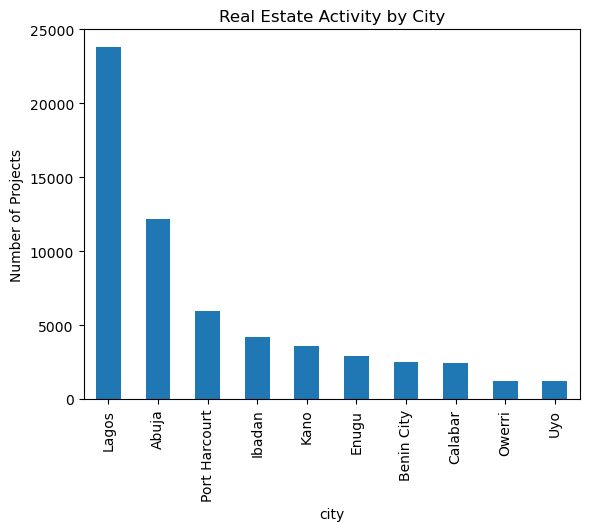

In [5]:
import matplotlib.pyplot as plt

df['city'].value_counts().plot(kind='bar')

plt.title("Real Estate Activity by City")
plt.ylabel("Number of Projects")
plt.show()

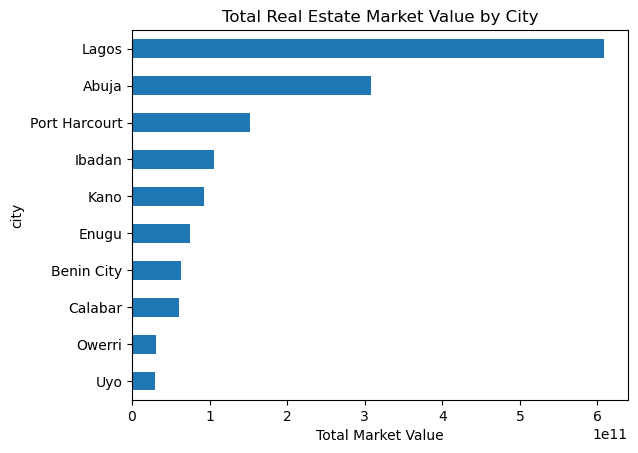

In [6]:
df.groupby('city')['value'].sum().sort_values().plot(kind='barh')

plt.title("Total Real Estate Market Value by City")
plt.xlabel("Total Market Value")
plt.show()

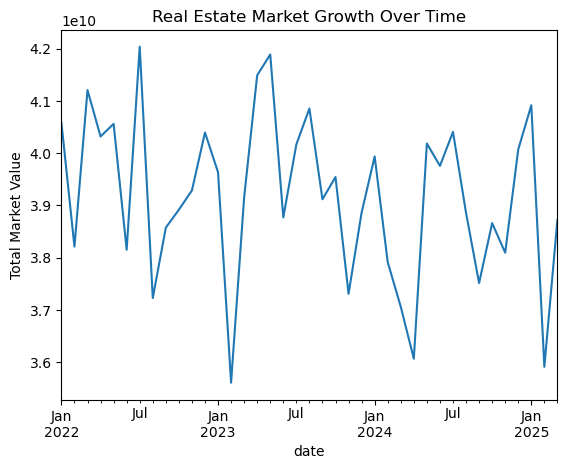

In [7]:
monthly = df.groupby(df['date'].dt.to_period('M'))['value'].sum()

monthly.plot()

plt.title("Real Estate Market Growth Over Time")
plt.ylabel("Total Market Value")
plt.show()

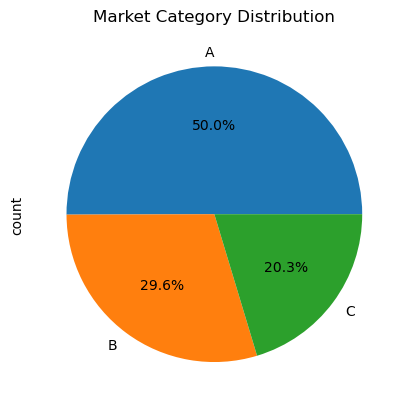

In [8]:
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Market Category Distribution")
plt.show()

#### Feature Engineering

_Creating new variables such as month and year for analysis._

In [9]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
le_cat = LabelEncoder()

df['city_encoded'] = le_city.fit_transform(df['city'])
df['category_encoded'] = le_cat.fit_transform(df['category'])

In [10]:
X = df[['city_encoded','category_encoded','month','year']]
y = df['value']

####  Machine Learning Model

_Training a model to predict property values._

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

####  Model Evaluation

_Evaluating model performance using MAE._

In [13]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 11847115.674818568


### Real estate market share by City

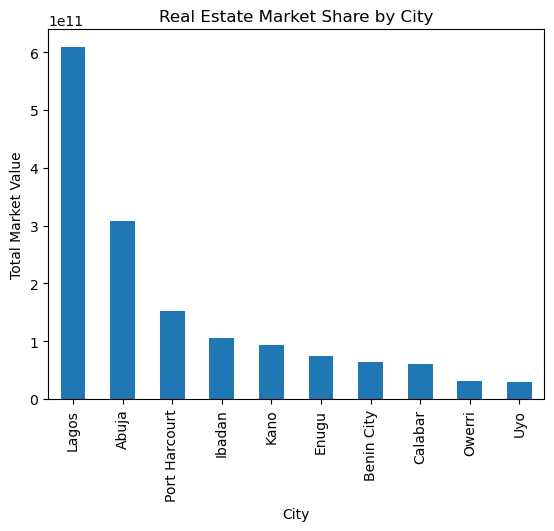

In [14]:
city_market = df.groupby('city')['value'].sum().sort_values(ascending=False)

city_market.plot(kind='bar')

plt.title("Real Estate Market Share by City")
plt.ylabel("Total Market Value")
plt.xlabel("City")
plt.show()

#### Construction Trend Forecast

In [15]:
df['date'] = pd.to_datetime(df['date'])

monthly_trend = df.groupby(df['date'].dt.to_period('M'))['value'].sum()
monthly_trend = monthly_trend.to_timestamp()

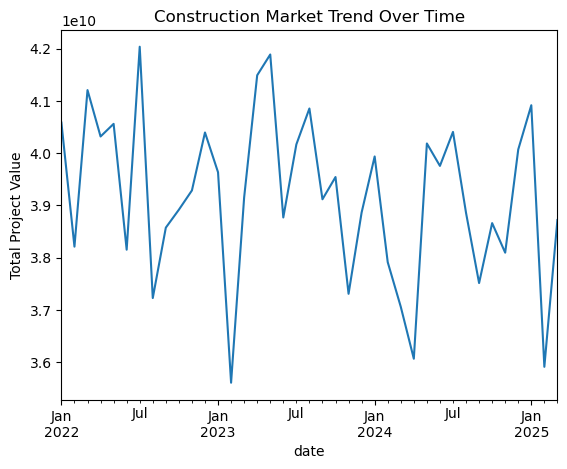

In [16]:
monthly_trend.plot()

plt.title("Construction Market Trend Over Time")
plt.ylabel("Total Project Value")
plt.show()

#### Forecast Future Construction Deamand

In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

monthly_trend = monthly_trend.reset_index()
monthly_trend['time_index'] = np.arange(len(monthly_trend))

X = monthly_trend[['time_index']]
y = monthly_trend['value']

model_trend = LinearRegression()
model_trend.fit(X,y)

monthly_trend['forecast'] = model_trend.predict(X)

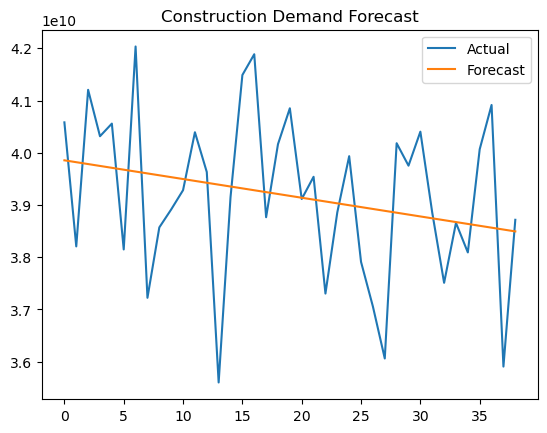

In [18]:
plt.plot(monthly_trend['value'], label='Actual')
plt.plot(monthly_trend['forecast'], label='Forecast')

plt.title("Construction Demand Forecast")
plt.legend()
plt.show()

#### High-Value Development Clusters 

#### Clustering Analysis

_Segmenting real estate developments into different market tiers._

In [19]:
from sklearn.cluster import KMeans

cluster_data = df[['value','city_encoded']]

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(cluster_data)

c:\Users\Emmanuel\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


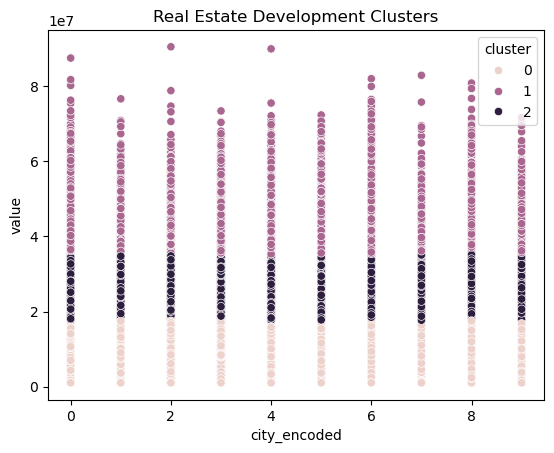

In [20]:
import seaborn as sns

sns.scatterplot(
    x='city_encoded',
    y='value',
    hue='cluster',
    data=df
)

plt.title("Real Estate Development Clusters")
plt.show()

#### Factors Driving Real Estate Value

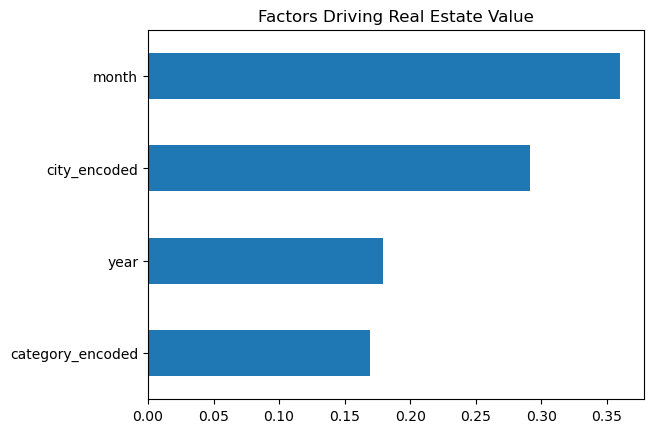

In [21]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Factors Driving Real Estate Value")
plt.show()

# Data Source

Dataset: Nigeria Real Estate – Market Supply Demand  
Source: Electric Sheep Africa (2025)

# Citation

@dataset{nigeria_realestate_2025,
  title = {Nigeria Real Estate – Market Supply Demand},
  author = {Electric Sheep Africa},
  year = {2025},
  publisher = {Hugging Face},
  url = {https://huggingface.co/datasets/electricsheepafrica/nigerian_realestate_market_supply_demand}
}